<a href="https://colab.research.google.com/github/RandiBro234/Feature-Engineering---Machine-Learning-Ops---Randi-Nandika-Danendra/blob/main/3324600013_Feature_Engineering_(1)_Randi_Nandika_Danendra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Dengan menggunakan data california_dataset.csv

a. Splitting Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
df_california = pd.read_csv('california_dataset.csv')
df_california

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state = 42)

In [ ]:
columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

train_data = train_clfr[columns].copy()
test_data  = test_clfr[columns].copy()

print(train_data.shape)

(16512, 5)


b. Looping Plot

Sebelum (MedInc)

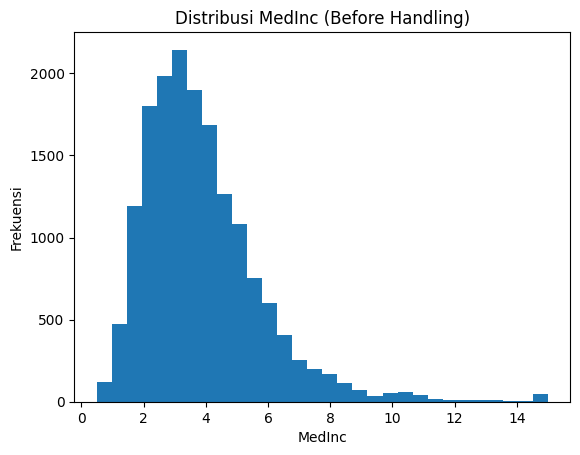

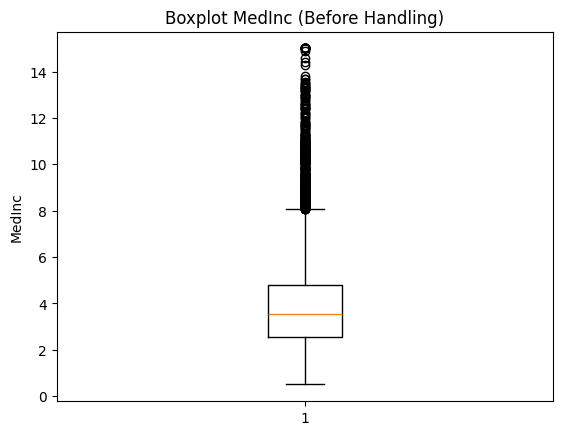

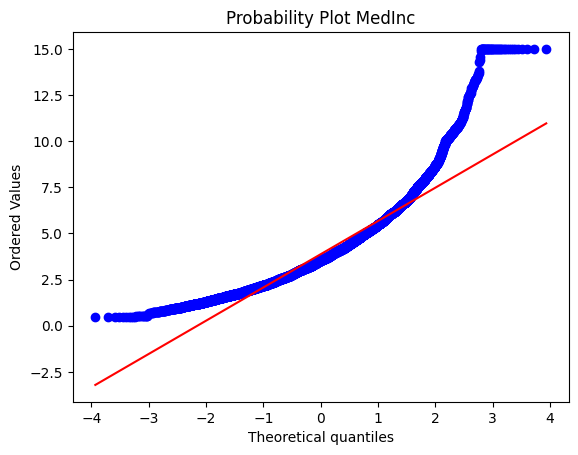

In [ ]:
# Ambil kolom MedInc dari data train
medinc = train_clfr['MedInc'].copy()

# Histogram
plt.figure()
plt.hist(train_data['MedInc'], bins=30)
plt.title("Distribusi MedInc (Before Handling)")
plt.xlabel("MedInc")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(train_data['MedInc'])
plt.title("Boxplot MedInc (Before Handling)")
plt.ylabel("MedInc")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(train_data['MedInc'], dist="norm", plot=plt)
plt.title("Probability Plot MedInc")
plt.show()

Pada variabel Meidan Income atau Pendapatan Median penduduk di suatu blok dari ketiga visuallisasi diatas memang terlihat jelas bahwa ada outlier di masing masing chart, misal pada histogram chart terlihat sebaran data lebih dominan di range 1-5 dan sedikit sekali untuk range dari 10-15

Handling Outlier dengan menggunaakan Capping (Tidak ada pengurangan baris)

In [ ]:
Q1 = medinc.quantile(0.25)
Q3 = medinc.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

Lower limit: -0.7430125000000003
Upper limit: 8.0828875


Dari hasil lower limit dan upper limit mengartikan bahwa data dengan range
-0.74 hingga 8.08 merupakan data normal yang bukan trmasuk outlier yang artinya jika ada nilai MedInc kurang dari -0.74 maka akan dianggap outlier begitupun jika lebih dari 8.08 akan dianggap outlier juga

In [ ]:
# ====== CAPPING (REPLACE) ======
medinc_capped = np.where(medinc > upper, upper,
                  np.where(medinc < lower, lower, medinc))

# Simpan kembali ke train_clfr (kolom MedInc saja yang berubah)
train_clfr['MedInc_capped'] = medinc_capped

print("Jumlah data tetap:", len(medinc_capped))

Jumlah data tetap: 16512


Kalau nilai MedInc lebih besar dari batas atas → ganti dengan upper,
Kalau nilai MedInc lebih kecil dari batas bawah → ganti dengan lower,
Kalau masih dalam batas → biarkan seperti semula

Sesudah Handling Outlier

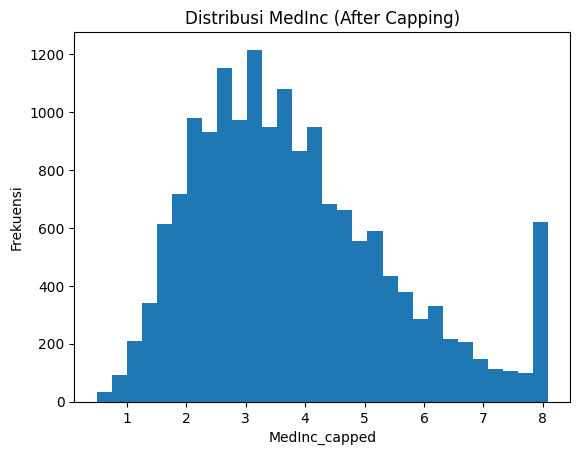

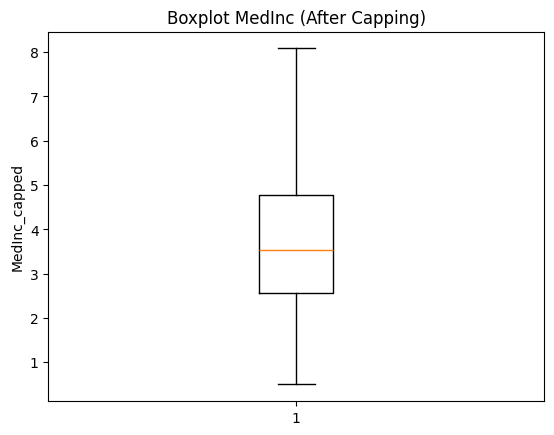

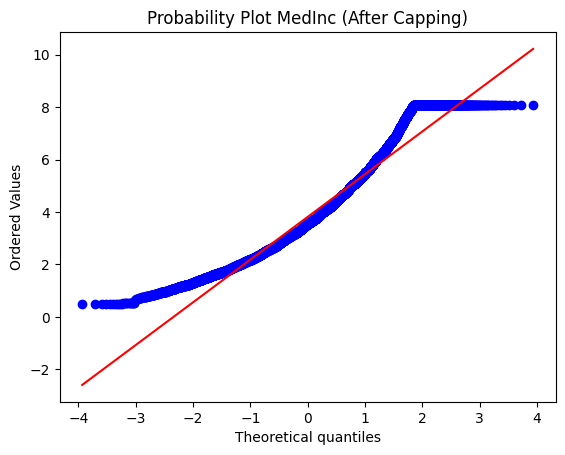

In [ ]:
# ====== PLOT SESUDAH CAPPING ======
plt.figure()
plt.hist(train_clfr['MedInc_capped'], bins=30)
plt.title("Distribusi MedInc (After Capping)")
plt.xlabel("MedInc_capped")
plt.ylabel("Frekuensi")
plt.show()

plt.figure()
plt.boxplot(train_clfr['MedInc_capped'])
plt.title("Boxplot MedInc (After Capping)")
plt.ylabel("MedInc_capped")
plt.show()

plt.figure()
stats.probplot(train_clfr['MedInc_capped'], dist="norm", plot=plt)
plt.title("Probability Plot MedInc (After Capping)")
plt.show()

Untuk hasil dari handling outlier sudah terlihat sedikit lebih clean daripada sebelumnya meski masih ada beberapa anomali yang terdeteksi seperti pada probability plot yang masih ada sedikit yang menyimpang sedangkan di boxplot sudah terlihat tidak ada anomali di atas garis wisker

Sebelum (HouseAge)

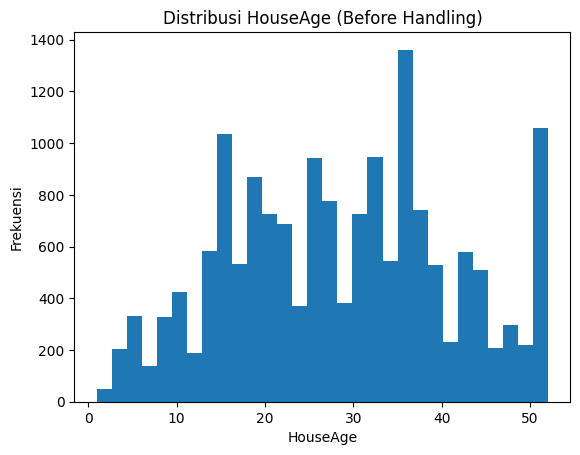

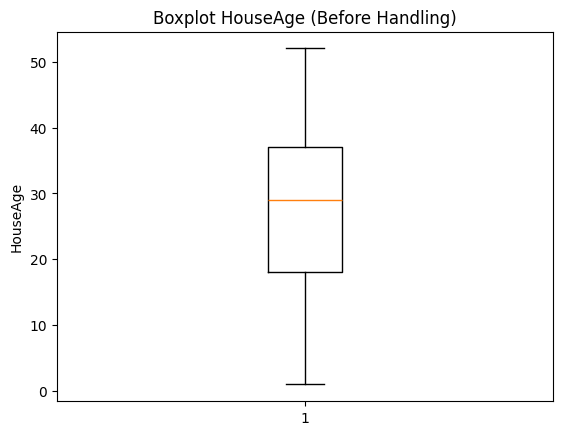

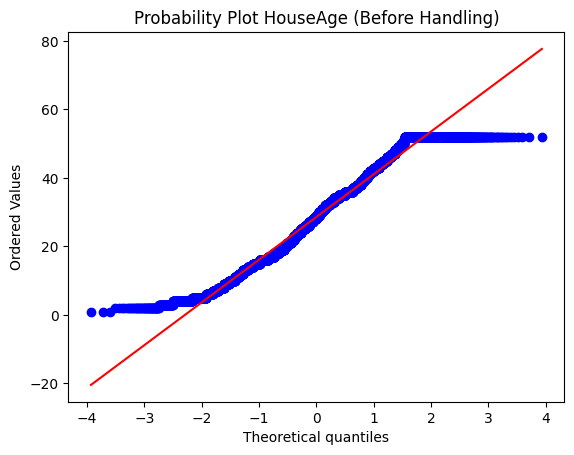

In [ ]:
houseage = train_clfr['HouseAge'].copy()

# Histogram
plt.figure()
plt.hist(houseage, bins=30)
plt.title("Distribusi HouseAge (Before Handling)")
plt.xlabel("HouseAge")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(houseage)
plt.title("Boxplot HouseAge (Before Handling)")
plt.ylabel("HouseAge")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(houseage, dist="norm", plot=plt)
plt.title("Probability Plot HouseAge (Before Handling)")
plt.show()

In [ ]:
houseage = train_clfr['HouseAge'].copy()

# Hitung IQR
Q1 = houseage.quantile(0.25)
Q3 = houseage.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

# Trimming (Drop outlier)
train_trimmed = train_clfr[
    (train_clfr['HouseAge'] >= lower) &
    (train_clfr['HouseAge'] <= upper)
]

print("Jumlah data sebelum:", len(train_clfr))
print("Jumlah data sesudah :", len(train_trimmed))

Lower limit: -10.5
Upper limit: 65.5
Jumlah data sebelum: 16512
Jumlah data sesudah : 16512


Plot Sesudah Handling

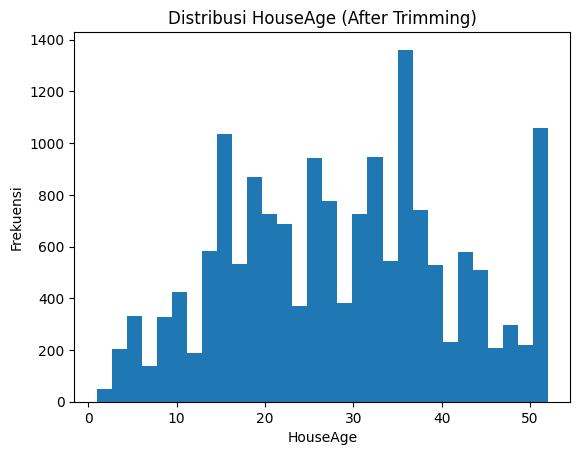

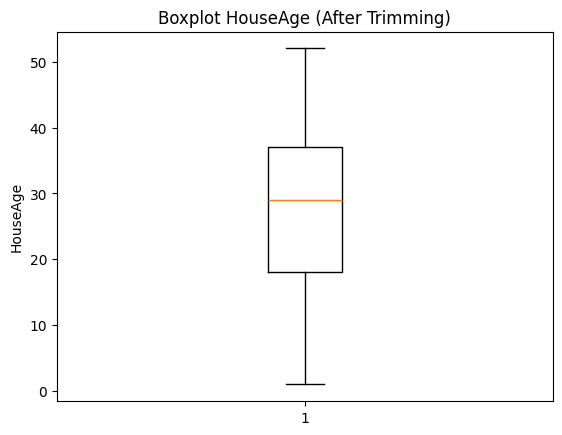

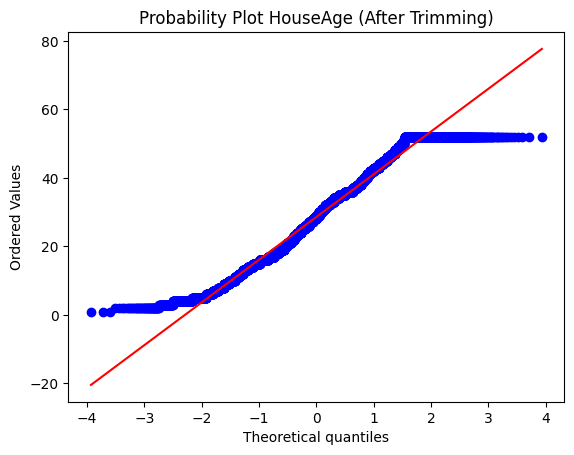

In [ ]:
# Histogram
plt.figure()
plt.hist(train_trimmed['HouseAge'], bins=30)
plt.title("Distribusi HouseAge (After Trimming)")
plt.xlabel("HouseAge")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(train_trimmed['HouseAge'])
plt.title("Boxplot HouseAge (After Trimming)")
plt.ylabel("HouseAge")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(train_trimmed['HouseAge'], dist="norm", plot=plt)
plt.title("Probability Plot HouseAge (After Trimming)")
plt.show()

Kenapa tidak ada perubahan karena memang pada variabel ini tidak ada outlier, dimana ketika saya menggunakan trimming tidak ada baris yang hilang yang seharusnya kalau saya menggunakan metode trimming ini itu ada baris yang dihilangkan jika terdapat outlier pada variabel tersebut

Sebelum (AveRoom)

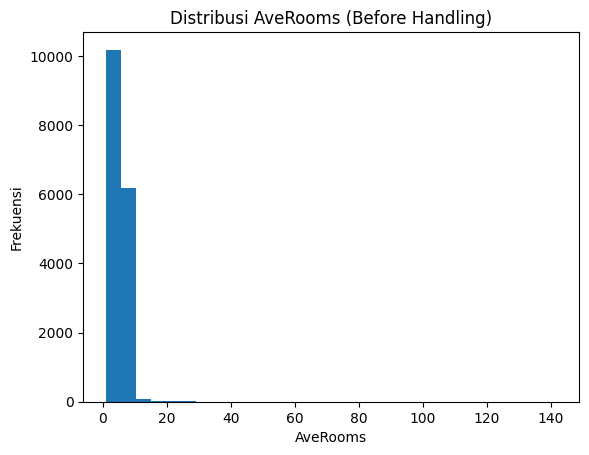

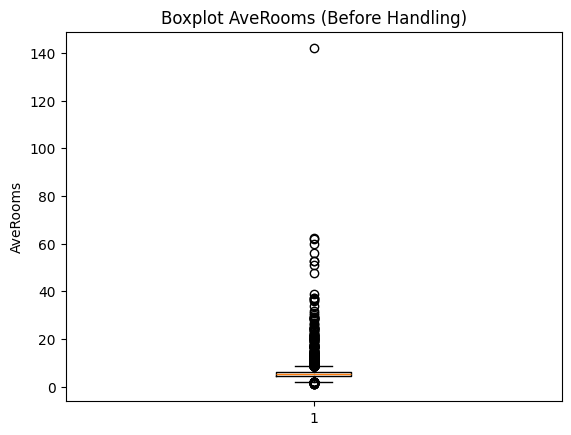

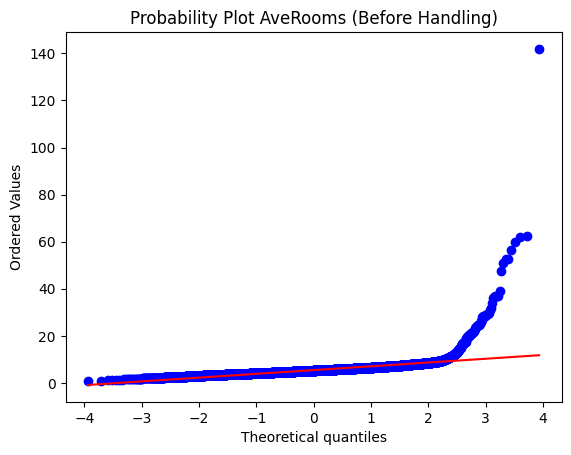

In [ ]:
averooms = train_clfr['AveRooms'].copy()

# Histogram
plt.figure()
plt.hist(averooms, bins=30)
plt.title("Distribusi AveRooms (Before Handling)")
plt.xlabel("AveRooms")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(averooms)
plt.title("Boxplot AveRooms (Before Handling)")
plt.ylabel("AveRooms")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(averooms, dist="norm", plot=plt)
plt.title("Probability Plot AveRooms (Before Handling)")
plt.show()

Pada data before handling terlihat pada histogram itu terjadi kecondongan ke arah kiri di kisaran 3-7 dan ada ekor panjang sampai 140, untuk boxplot sangat banyak titik diatas garis wisker dan ada nilai ekstrim diatas 100, sedangkan di probability plot terlihat kecondongan ke arah kanan yang tidak seliniear dengan garis merah sehingga distribusi tidak normal

In [ ]:
Q1 = averooms.quantile(0.25)
Q3 = averooms.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

Lower limit: 2.0385818023548827
Upper limit: 8.474509781463325


In [ ]:
train_trimmed_rooms = train_clfr[
    (train_clfr['AveRooms'] >= lower) &
    (train_clfr['AveRooms'] <= upper)
]

print("Jumlah data sebelum:", len(train_clfr))
print("Jumlah data sesudah :", len(train_trimmed_rooms))

Jumlah data sebelum: 16512
Jumlah data sesudah : 16102


Sesudah Capping

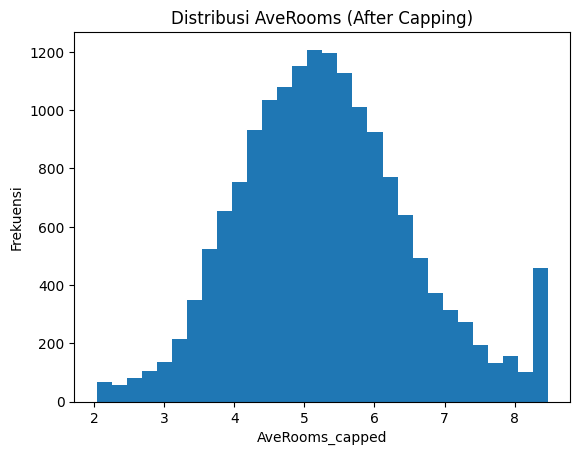

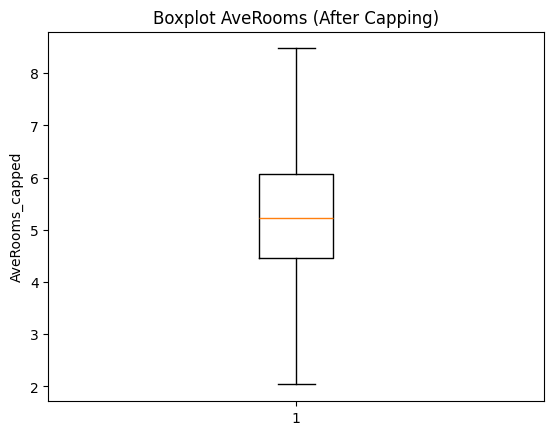

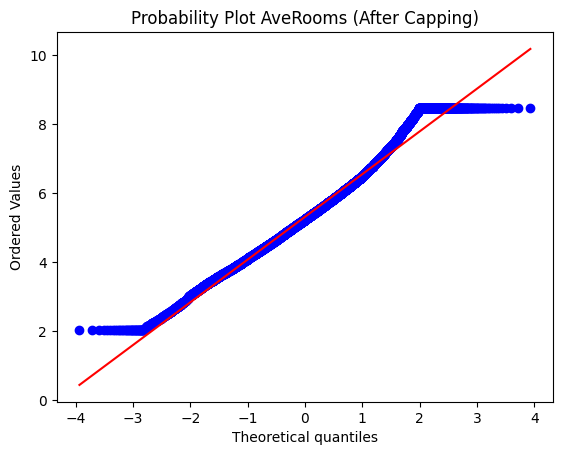

In [ ]:
# Capping for AveRooms
Q1_rooms = train_clfr['AveRooms'].quantile(0.25)
Q3_rooms = train_clfr['AveRooms'].quantile(0.75)
IQR_rooms = Q3_rooms - Q1_rooms

lower_rooms = Q1_rooms - 1.5 * IQR_rooms
upper_rooms = Q3_rooms + 1.5 * IQR_rooms

train_clfr['AveRooms_capped'] = np.clip(train_clfr['AveRooms'], lower_rooms, upper_rooms)

# Histogram
plt.figure()
plt.hist(train_clfr['AveRooms_capped'], bins=30)
plt.title("Distribusi AveRooms (After Capping)")
plt.xlabel("AveRooms_capped")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(train_clfr['AveRooms_capped'])
plt.title("Boxplot AveRooms (After Capping)")
plt.ylabel("AveRooms_capped")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(train_clfr['AveRooms_capped'], dist="norm", plot=plt)
plt.title("Probability Plot AveRooms (After Capping)")
plt.show()

Setelah saya lakukan capping handling dimana ada data yang jauh menyimpang > 140 itu replace dengan upper_limit karena hanya sedikit data yang menyimpang di area itu, takutnya malah akan kehilangan informasi meskipun dia bernilai ekstrim dan model tidak akan tau bahwa ternyata rumah besar itu ada pada dataset

Sebelum (AveBdrms)

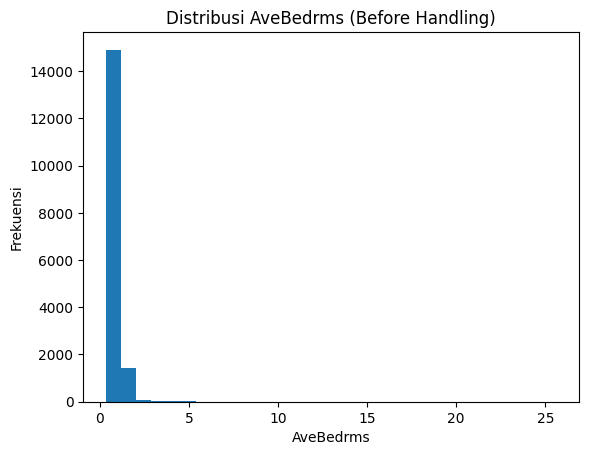

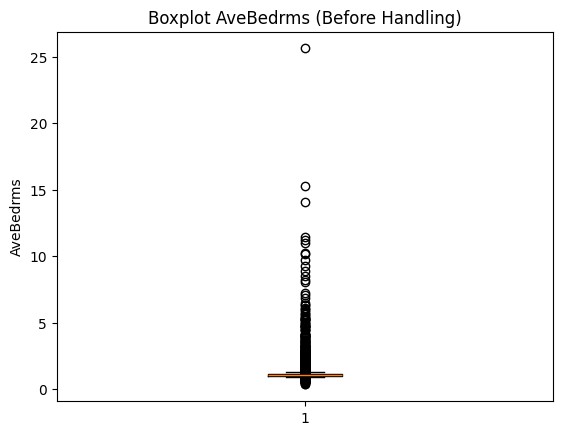

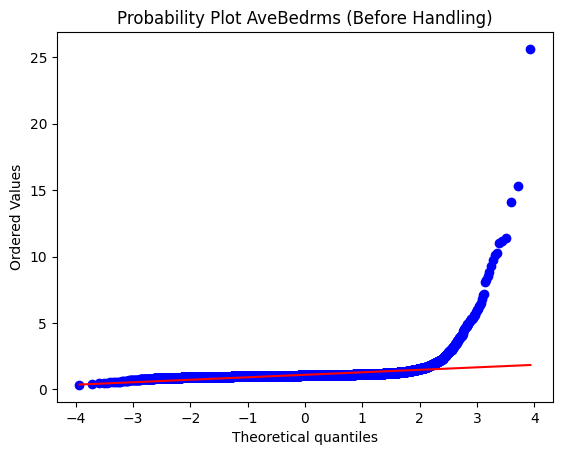

In [ ]:
avebed = train_clfr['AveBedrms'].copy()

# Histogram
plt.figure()
plt.hist(avebed, bins=30)
plt.title("Distribusi AveBedrms (Before Handling)")
plt.xlabel("AveBedrms")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(avebed)
plt.title("Boxplot AveBedrms (Before Handling)")
plt.ylabel("AveBedrms")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(avebed, dist="norm", plot=plt)
plt.title("Probability Plot AveBedrms (Before Handling)")
plt.show()

Yap kurang lebih sama dengan sebelumnya untuk plot deteksi outlier ini

In [ ]:
Q1 = avebed.quantile(0.25)
Q3 = avebed.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

Lower limit: 0.8657476648673017
Upper limit: 1.2411074710635364


In [ ]:
avebed_capped = np.clip(avebed, lower, upper)

train_clfr['AveBedrms_capped'] = avebed_capped

print("Jumlah data tetap:", len(avebed_capped))

Jumlah data tetap: 16512


Setelah Capping

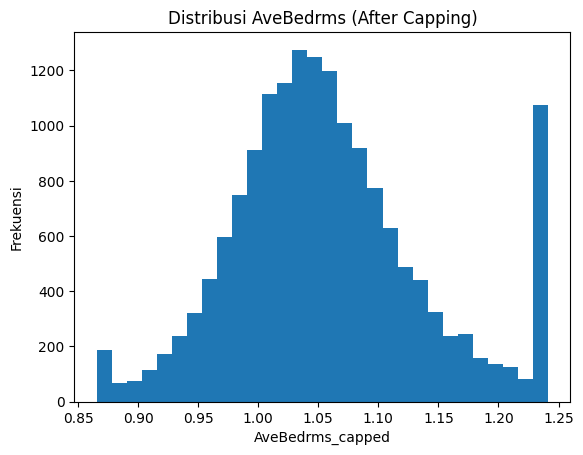

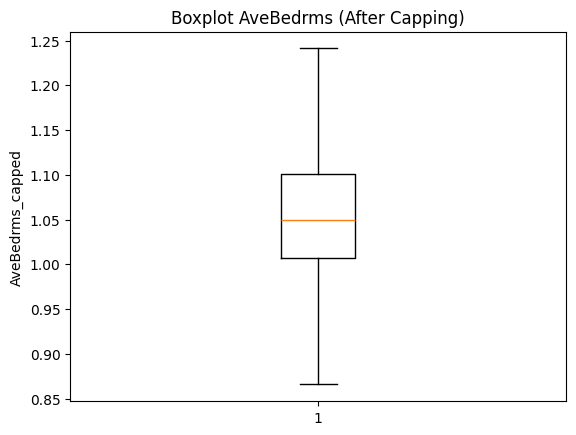

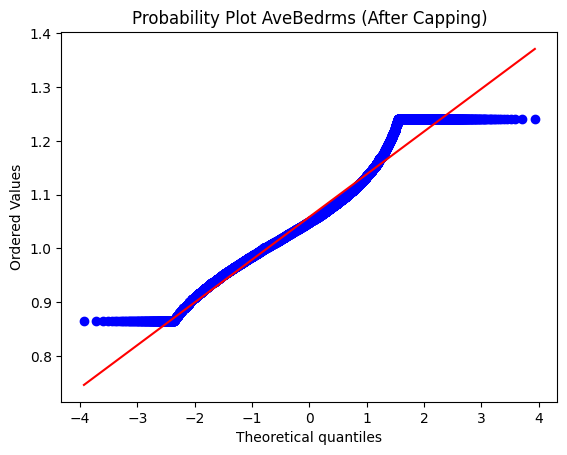

In [ ]:
# Histogram
plt.figure()
plt.hist(train_clfr['AveBedrms_capped'], bins=30)
plt.title("Distribusi AveBedrms (After Capping)")
plt.xlabel("AveBedrms_capped")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(train_clfr['AveBedrms_capped'])
plt.title("Boxplot AveBedrms (After Capping)")
plt.ylabel("AveBedrms_capped")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(train_clfr['AveBedrms_capped'], dist="norm", plot=plt)
plt.title("Probability Plot AveBedrms (After Capping)")
plt.show()

Yap masih sama juga kurang lebih dengan variabel sebelumnya

Sebelum (AveOccup) = Rata Rata Jumlah Orang per Rumah Tangga

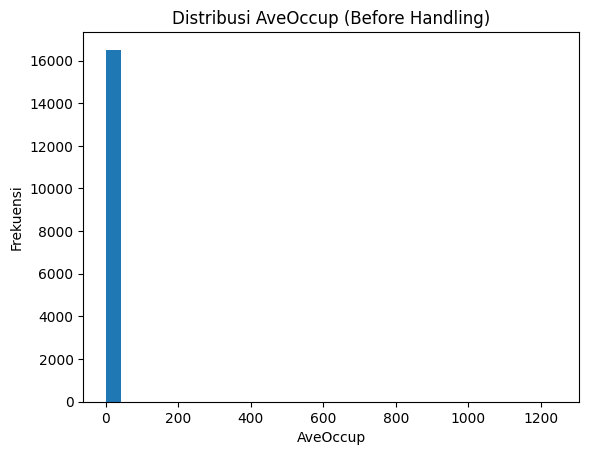

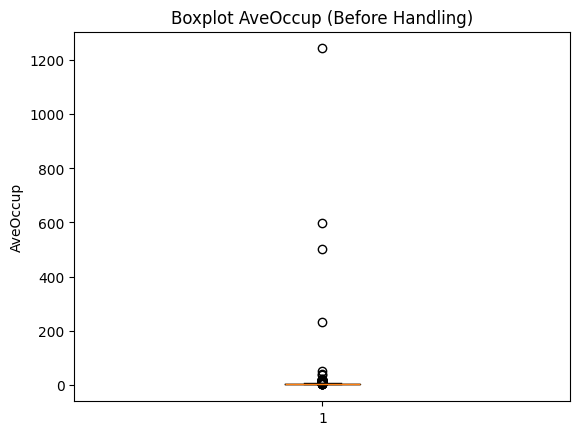

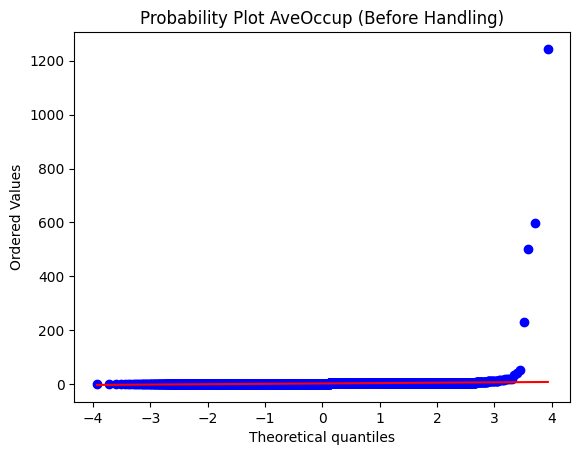

In [ ]:
aveoccup = train_clfr['AveOccup'].copy()

# Histogram
plt.figure()
plt.hist(aveoccup, bins=30)
plt.title("Distribusi AveOccup (Before Handling)")
plt.xlabel("AveOccup")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(aveoccup)
plt.title("Boxplot AveOccup (Before Handling)")
plt.ylabel("AveOccup")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(aveoccup, dist="norm", plot=plt)
plt.title("Probability Plot AveOccup (Before Handling)")
plt.show()

Wop terlihat jelas sekali lumayan banyak nilai ekstrim pada ketiga plot, yang terlihat jelas itu pada histogram dimana sebaran data paling banyak di kisaran 1-5 sedangkan datanya ada yang samapai 1200 dan pada boxplot ada beberapa data yang berada di atas garis whisker

In [ ]:
aveoccup = train_clfr['AveOccup'].copy()

Q1 = aveoccup.quantile(0.25)
Q3 = aveoccup.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

Lower limit: 1.1519972702456773
Upper limit: 4.556801637852593


In [ ]:
train_trimmed_occ = train_clfr[
    (train_clfr['AveOccup'] >= lower) &
    (train_clfr['AveOccup'] <= upper)
]

print("Jumlah data sebelum:", len(train_clfr))
print("Jumlah data sesudah :", len(train_trimmed_occ))

Jumlah data sebelum: 16512
Jumlah data sesudah : 15930


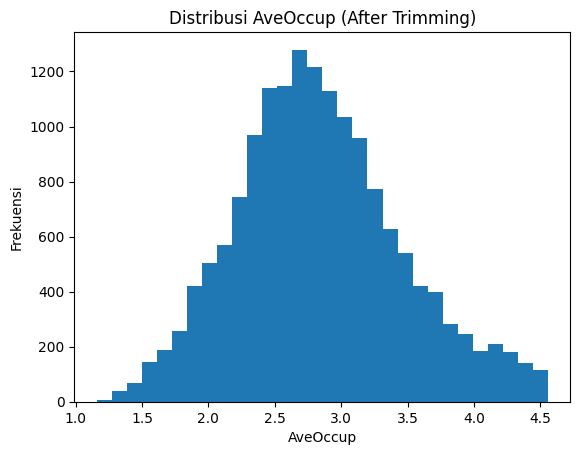

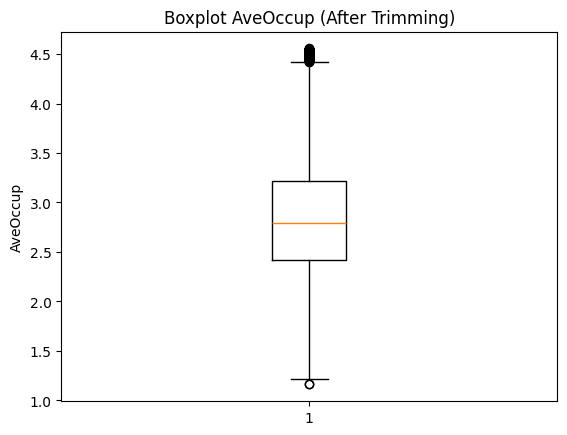

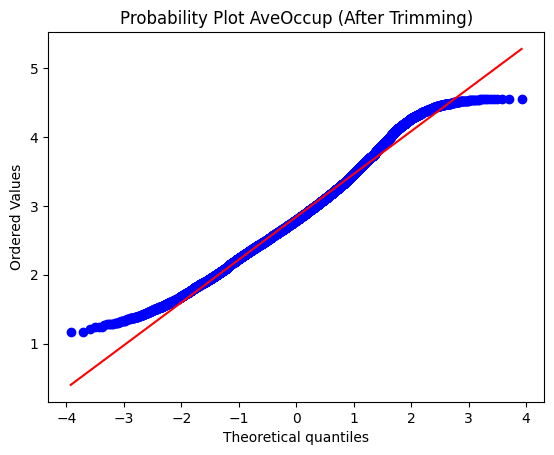

In [ ]:
# Histogram
plt.figure()
plt.hist(train_trimmed_occ['AveOccup'], bins=30)
plt.title("Distribusi AveOccup (After Trimming)")
plt.xlabel("AveOccup")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(train_trimmed_occ['AveOccup'])
plt.title("Boxplot AveOccup (After Trimming)")
plt.ylabel("AveOccup")
plt.show()

# Probability Plot
plt.figure()
stats.probplot(train_trimmed_occ['AveOccup'], dist="norm", plot=plt)
plt.title("Probability Plot AveOccup (After Trimming)")
plt.show()

Disini kenapa saya menggunakan trimming, karena sangat tidak mungkin dalam satu rumah itu ada 200 bahkan lebih dari itu untuk menghuni satu rumah, dan terlihat jelas distribusi pada plot hsistogram menjadi lebih normal dan tidak ada kecondongan sama sekali, di boxplot juga terlihat maksimal itu ada di angka 4.5 menuju 5 dan menurut saya itu adalah normal, serta pada probability plot sudah sangat linear dengan garis merah untuk biru biru nya tidak seperti sebelumnya

# 2. Menggunakan dataset company.csv

In [ ]:
df_company = pd.read_csv('company.csv')
df_company

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"
...,...,...,...,...
667,Unknown / Non-Applicable,1001 to 5000 employees,3.6,"Fort Lee, NJ"
668,-1,-1,-1.0,-1
669,-1,-1,-1.0,-1
670,$1 to $5 million (USD),1 to 50 employees,5.0,"Santa Clara, CA"


a. Splitting Data

In [ ]:
train_company, test_company = train_test_split(
    df_company,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_company))
print("Test size :", len(test_company))

Train size: 537
Test size : 135


b. Cek persentase missing value Heartquartes

In [ ]:
# Cek NaN
print("Missing NaN:")
print(train_company['Headquarters'].isna().sum())

# Cek nilai -1
print("Jumlah -1:")
print((train_company['Headquarters'] == -1).sum())

Missing NaN:
0
Jumlah -1:
0


In [ ]:
total = len(train_company)
missing_count = (train_company['Headquarters'] == -1).sum()

missing_percentage = (missing_count / total) * 100

print("Persentase Missing Headquarters:", round(missing_percentage, 2), "%")

Persentase Missing Headquarters: 0.0 %


c. Handling Missiing Value

In [ ]:
train_company['Headquarters'] = train_company['Headquarters'].replace(-1, "Unknown")
test_company['Headquarters'] = test_company['Headquarters'].replace(-1, "Unknown")

In [ ]:
print((train_company['Headquarters'] == -1).sum())

0


Missing value pada Headquarters terdeteksi dalam bentuk nilai -1, Bukan NaN, sehingga perlu pengecekan khusus. Handling dilakukan dengan mengganti nilai -1 menjadi "Unknown" Karena:
- Headquarters adalah data kategorikal
- Tidak bisa dihitung mean/median
- Menghapus data bisa menghilangkan informasi

# 3. Dengan menggunakan data Telco-Customer-Churn.csv

Splitting Data

In [ ]:
df_customer = pd.read_csv('Telco-Customer-Churn.csv')
df_customer

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


a. Label Encode pada Partner & Dependents

In [ ]:
# Bersihkan dulu spasi kalau ada
df_customer['Partner'] = df_customer['Partner'].str.strip()
df_customer['Dependents'] = df_customer['Dependents'].str.strip()

In [ ]:
train_cust, test_cust = train_test_split(
    df_customer,
    test_size=0.2,
    random_state=42)

In [ ]:
# Mapping Yes/No jadi 1/0
df_customer['Partner'] = df_customer['Partner'].map({'Yes': 1, 'No': 0})
df_customer['Dependents'] = df_customer['Dependents'].map({'Yes': 1, 'No': 0})

df_customer[['Partner','Dependents']].head()

,Partner,Dependents
0,1,0
1,0,0
2,0,0
3,0,0
4,0,0


b. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines

In [ ]:
selected_cols = [
    'StreamingMovies', 'StreamingTV', 'TechSupport',
    'DeviceProtection', 'OnlineBackup', 'OnlineSecurity',
    'MultipleLines'
]

df_selected = df_customer[selected_cols].copy()

for col in selected_cols:
    print(col, ":", df_selected[col].unique())

df_selected.head()

StreamingMovies : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
OnlineSecurity : ['No' 'Yes' 'No internet service']
MultipleLines : ['No phone service' 'No' 'Yes']


,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,No,No,No,No,Yes,No,No phone service
1,No,No,No,Yes,No,Yes,No
2,No,No,No,No,Yes,Yes,No
3,No,No,Yes,Yes,No,Yes,No phone service
4,No,No,No,No,No,No,No


Terlihat pada output diatas bahwa ada tiga jenis unik value yang membuat pemodelan nanti tidak akan berjalan dengan maksimal, maka dari itu perlu kita encode buat No Internet Service menjadi No saja agar astu varian dengan No biasa

c. Ubah yang No Internet Service dan No Phone Service menjadi No saja

In [ ]:
df_customer['StreamingMovies'] = df_customer['StreamingMovies'].replace({'No internet service' : 'No'})
df_customer['StreamingTV'] = df_customer['StreamingTV'].replace({'No internet service' : 'No'})
df_customer['TechSupport'] = df_customer['TechSupport'].replace({'No internet service' : 'No'})
df_customer['DeviceProtection'] = df_customer['DeviceProtection'].replace({'No internet service' : 'No'})
df_customer['OnlineBackup'] = df_customer['OnlineBackup'].replace({'No internet service' : 'No'})
df_customer['OnlineSecurity'] = df_customer['OnlineSecurity'].replace({'No internet service' : 'No'})
df_customer['MultipleLines'] = df_customer['MultipleLines'].replace({'No phone service' : 'No'})

In [ ]:
for column in selected_cols:
  print(f"=========={column}==========")
  display(df_customer[column].value_counts())
  print()

==========StreamingMovies==========


,count
StreamingMovies,
No,4311
Yes,2732



==========StreamingTV==========


,count
StreamingTV,
No,4336
Yes,2707



==========TechSupport==========


...

,count
OnlineBackup,
No,4614
Yes,2429



==========OnlineSecurity==========


,count
OnlineSecurity,
No,5024
Yes,2019



==========MultipleLines==========


,count
MultipleLines,
No,4072
Yes,2971


Sudah berhasil di encode sehingga No Internet Service dan No Phone Service sudah menjadi No biasa

d. Lakukan Label Encoder (Mengubahnya menjadi biner 1 atau 0)

In [ ]:
# Inisiasi Label Encoder
label_encoder = LabelEncoder()

In [ ]:
encoders = {}

for col in selected_cols:
    le = LabelEncoder()
    train_cust[col] = le.fit_transform(train_cust[col])
    test_cust[col]  = test_cust[col].replace({'No internet service':'No', 'No phone service':'No'})
    test_cust[col]  = le.transform(test_cust[col])
    encoders[col] = le

In [ ]:
# Cek apakah sudah ter encode
for col in selected_cols:
    print(col, encoders[col].classes_)

StreamingMovies [0 1 2]
StreamingTV [0 1 2]
TechSupport [0 1 2]
DeviceProtection [0 1 2]
OnlineBackup [0 1 2]
OnlineSecurity [0 1 2]
MultipleLines [0 1 2]


e. Lakukan Mean Encoding pada InternetService (mengganti kategori pada InternetService dengan rata-rata nilai target (Churn) pada masing-masing kategori)

In [ ]:
# Lakukan Encode pada variabel Churn
train_cust['Churn'] = train_cust['Churn'].map({'No': 0, 'Yes': 1})
test_cust['Churn']  = test_cust['Churn'].map({'No': 0, 'Yes': 1})

In [ ]:
# Hitung Mean Encoding di TRAIN
mean_encoding = train_cust.groupby('InternetService')['Churn'].mean()
mean_encoding

,Churn
InternetService,
DSL,0.191851
Fiber optic,0.415558
No,0.076606


In [ ]:
# Terapkan ke Train
train_cust['InternetService_ME'] = train_cust['InternetService'].map(mean_encoding)

In [ ]:
# Terapkan ke Test (pakai mapping dari train)
test_cust['InternetService_ME'] = test_cust['InternetService'].map(mean_encoding)

In [ ]:
# Cek Hasil
train_cust[['InternetService', 'InternetService_ME']].head()

,InternetService,InternetService_ME
2142,DSL,0.191851
1623,Fiber optic,0.415558
6074,DSL,0.191851
1362,Fiber optic,0.415558
6754,DSL,0.191851


Mean Encoding dilakukan pada kolom InternetService dengan menghitung rata-rata nilai Churn pada data training. Nilai rata-rata tersebut kemudian dipetakan kembali ke data training dan testing untuk menghindari data leakage.

# Dengan menggunakan data Telco-Customer-Churn.csv kolom TotalCharges

a. Mengganti nilai yang tidak valid (kosong atau spasi) dengan NaN

In [ ]:
# Ganti string kosong atau spasi jadi NaN
df_customer['TotalCharges'] = df_customer['TotalCharges'].replace(" ", np.nan)

b. Mengubah kolom menjadi tipe float dan juga menggunakan pd.to_numeric serta
errors='coerce'

In [ ]:
df_customer['TotalCharges'] = pd.to_numeric(df_customer['TotalCharges'], errors='coerce')
df_customer['TotalCharges'].dtype

dtype('float64')

c. Cek Missing Value

In [ ]:
missing_count = df_customer['TotalCharges'].isna().sum()
total = len(df_customer)
missing_percentage = (missing_count / total) * 100

print("Jumlah Missing:", missing_count)
print("Persentase Missing:", round(missing_percentage,2), "%")

Jumlah Missing: 11
Persentase Missing: 0.16 %


d. Imputasi Missing Value

In [ ]:
median_value = df_customer['TotalCharges'].median()

df_customer['TotalCharges'] = df_customer['TotalCharges'].fillna(median_value)

e. Pastikan Tidak Ada NaN Lagi

In [ ]:
print(df_customer['TotalCharges'].isna().sum())

0


f. Scaling: StandardScaler vs MinMaxScaler

In [ ]:
# StandarScaler
scaler_std = StandardScaler()
total_std = scaler_std.fit_transform(df_customer[['TotalCharges']])

In [ ]:
# MinMaxScaler
scaler_mm = MinMaxScaler()
total_mm = scaler_mm.fit_transform(df_customer[['TotalCharges']])

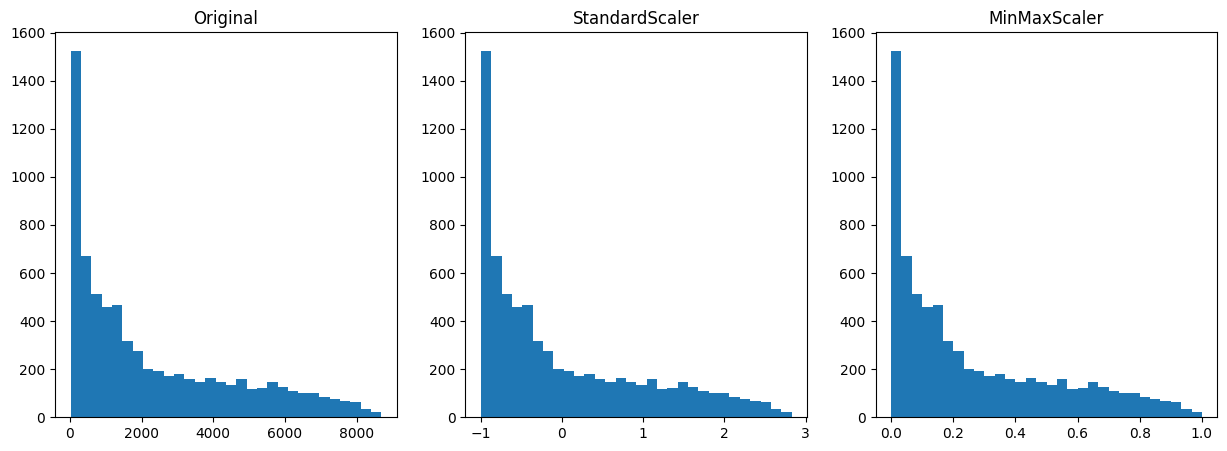

In [ ]:
# Plot Perbandingan
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(df_customer['TotalCharges'], bins=30)
plt.title("Original")

plt.subplot(1,3,2)
plt.hist(total_std, bins=30)
plt.title("StandardScaler")

plt.subplot(1,3,3)
plt.hist(total_mm, bins=30)
plt.title("MinMaxScaler")

plt.show()

Berdasarkan plot tersebut, distribusi `TotalCharges` pada data asli terlihat right-skewed dengan banyak nilai kecil dan sedikit nilai sangat besar. Setelah menggunakan StandardScaler, bentuk distribusi tetap sama tetapi sudah terstandarisasi dengan mean mendekati 0 dan skala yang lebih seimbang, sehingga lebih stabil untuk model seperti Logistic Regression atau SVM. Sementara itu, MinMaxScaler mengubah rentang data menjadi 0–1 tanpa mengubah bentuk distribusi, namun lebih sensitif terhadap outlier karena nilai besar dapat membuat sebagian besar data menumpuk di dekat 0.
